In [1]:
!pip install numpy pandas matplotlib scikit-learn


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Normalização e Padronização de Atributos — Wine Dataset

Atividade exploratória de Reconhecimento de Padrões: comparação visual dos dados antes e após a aplicação de técnicas de normalização (Min-Max) e padronização (Z-Score).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

## 1. Carregamento e exploração dos dados

In [3]:
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

print(f"Amostras: {df.shape[0]}, Atributos: {df.shape[1] - 1}")
print(f"Classes: {list(wine.target_names)}")
df.describe().round(2)

Amostras: 178, Atributos: 13
Classes: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89,0.94
std,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91,0.78
min,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00,0.00
25%,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.27,1.25,3.22,0.78,1.94,500.50,0.00
50%,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50,1.00
75%,13.68,3.08,2.56,21.50,107.00,2.80,2.88,0.44,1.95,6.20,1.12,3.17,985.00,2.00
max,14.83,5.80,3.23,30.00,162.00,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.00,2.00


### Observação sobre as escalas

Enorme diferença de escala entre os atributos. Por exemplo, `proline` varia na casa das centenas/milhares, enquanto `nonflavanoid_phenols` varia entre 0 e 1. Isso cria uma distorção geométrica no espaço de atributos.

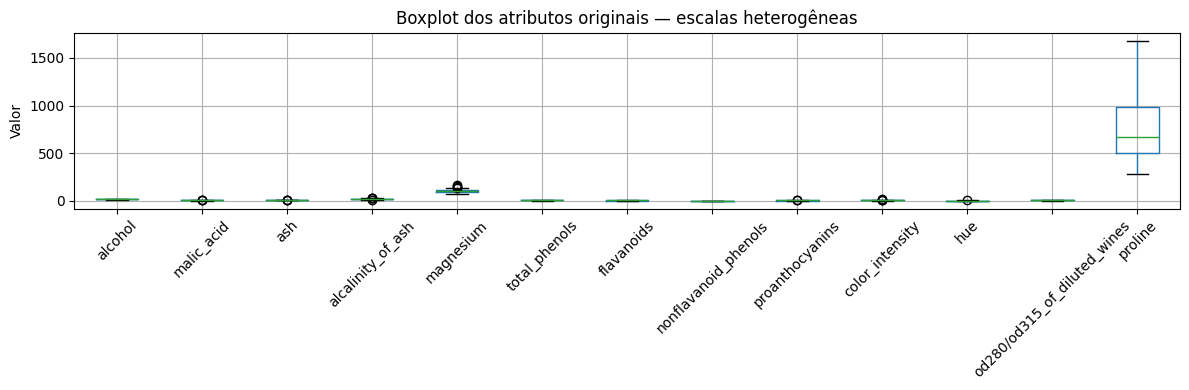

In [4]:
# Visualizar a disparidade de escalas via boxplot
fig, ax = plt.subplots(figsize=(12, 4))
df.drop(columns='target').boxplot(ax=ax, rot=45)
ax.set_title('Boxplot dos atributos originais — escalas heterogêneas')
ax.set_ylabel('Valor')
plt.tight_layout()
plt.savefig('boxplot_original.png', bbox_inches='tight')
plt.show()

## 2. Aplicação das técnicas de pré-processamento

In [5]:
X = df.drop(columns='target').values
y = df['target'].values
feature_names = wine.feature_names

# Padronização (Z-Score)
scaler_standard = StandardScaler()
X_standard = scaler_standard.fit_transform(X)

# Normalização Min-Max [0, 1]
scaler_minmax = MinMaxScaler()
X_minmax = scaler_minmax.fit_transform(X)

# Normalização Robusta (extra, para comparação)
scaler_robust = RobustScaler()
X_robust = scaler_robust.fit_transform(X)

print("Transformações aplicadas com sucesso.")

Transformações aplicadas com sucesso.


## 3. Comparação visual: Boxplots após cada transformação

C:\Users\ryanq\AppData\Local\Temp\ipykernel_8824\2808743683.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data[:, i] for i in range(data.shape[1])],
C:\Users\ryanq\AppData\Local\Temp\ipykernel_8824\2808743683.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data[:, i] for i in range(data.shape[1])],
C:\Users\ryanq\AppData\Local\Temp\ipykernel_8824\2808743683.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data[:, i] for i in range(data.shape[1])],
C:\Users\ryanq\AppData\Local\Temp\ipykernel_8824\2808743683.py:11: MatplotlibDeprecationWarning: The 'labe

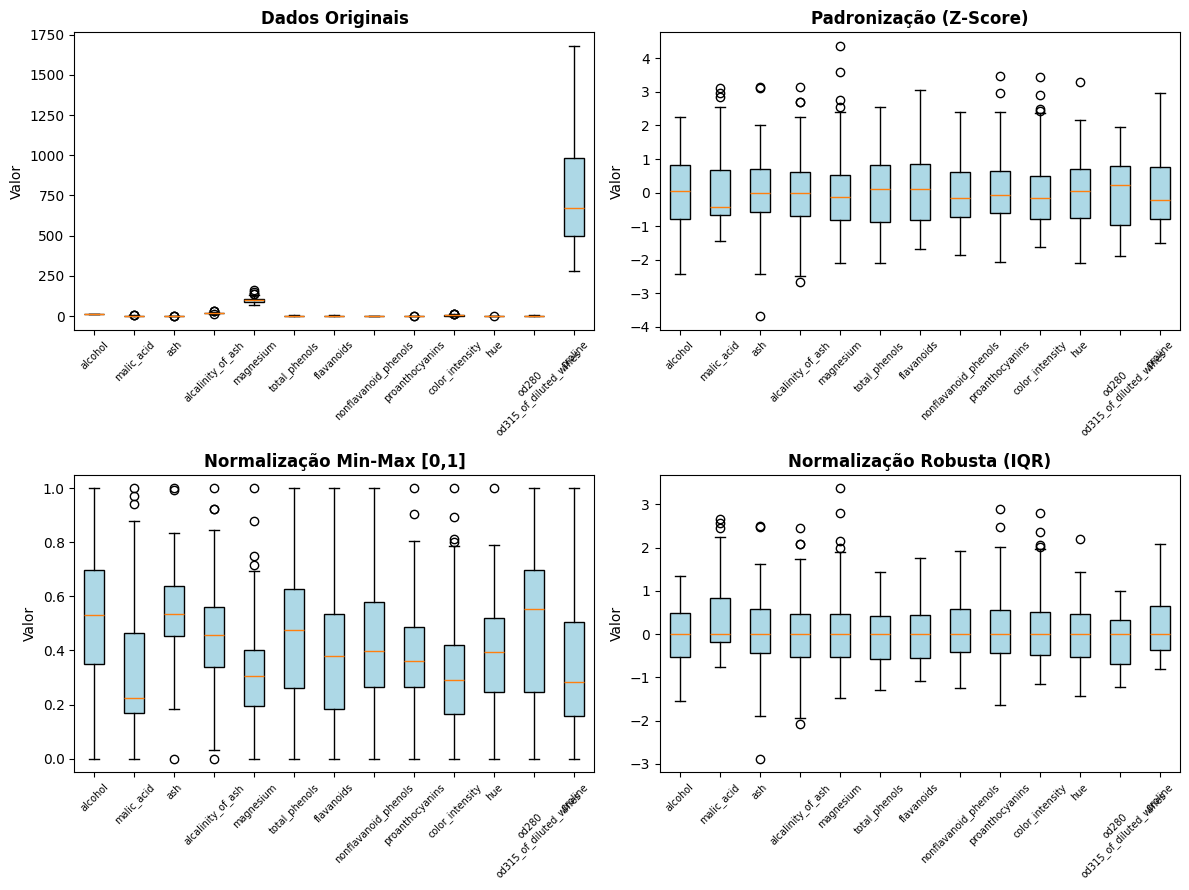

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

datasets = [
    (X, 'Dados Originais'),
    (X_standard, 'Padronização (Z-Score)'),
    (X_minmax, 'Normalização Min-Max [0,1]'),
    (X_robust, 'Normalização Robusta (IQR)')
]

for ax, (data, title) in zip(axes.flat, datasets):
    bp = ax.boxplot([data[:, i] for i in range(data.shape[1])],
                    labels=[f.replace('/', '\n') for f in feature_names],
                    patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
    ax.set_title(title, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.set_ylabel('Valor')

plt.tight_layout()
plt.savefig('boxplots_comparacao.png', bbox_inches='tight')
plt.show()

## 4. Comparação visual: Gráficos de dispersão 2D

Dois atributos com escalas muito diferentes — `proline` (centenas) e `nonflavanoid_phenols` (decimais) — para evidenciar o efeito geométrico das transformações.

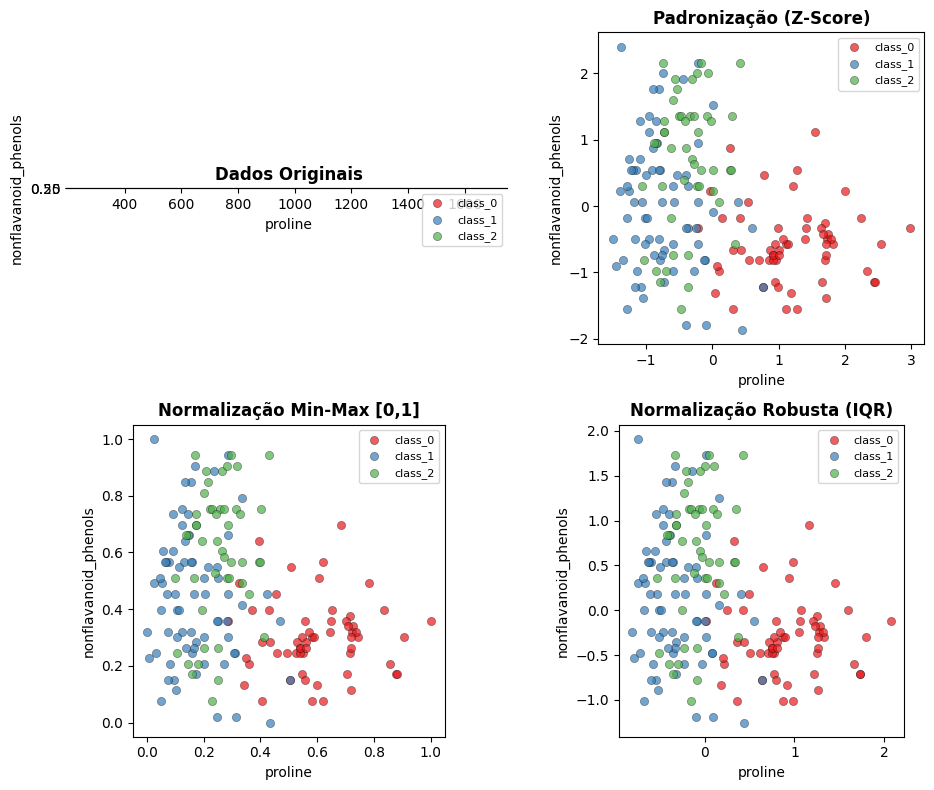

In [7]:
# Índices dos atributos escolhidos
idx_a = feature_names.index('proline')
idx_b = feature_names.index('nonflavanoid_phenols')

colors = ['#e41a1c', '#377eb8', '#4daf4a']
class_names = wine.target_names

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, (data, title) in zip(axes.flat, datasets):
    for c in range(3):
        mask = y == c
        ax.scatter(data[mask, idx_a], data[mask, idx_b],
                   c=colors[c], label=class_names[c],
                   alpha=0.7, edgecolors='k', linewidths=0.3, s=35)
    ax.set_xlabel(feature_names[idx_a])
    ax.set_ylabel(feature_names[idx_b])
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('dispersao_proline_nonflavanoid.png', bbox_inches='tight')
plt.show()

### Discussão do gráfico de dispersão

- **Dados originais**: com `aspect='equal'`, o eixo de `proline` (escala ~100–1700) domina completamente, e a variação em `nonflavanoid_phenols` (~0.1–0.7) é praticamente invisível. Geometricamente, os pontos estão "achatados" em uma faixa horizontal.
- **Após padronização (Z-Score)**: ambos os eixos têm variância ≈ 1. A nuvem de pontos se torna mais isotrópica e as classes ficam visualmente mais distinguíveis.
- **Após Min-Max**: ambos os eixos estão em [0, 1], mas a distribuição pode ser comprimida se houver outliers. A estrutura geométrica é parecida com Z-Score, mas a localização e escala são diferentes.
- **Após Robust Scaling**: similar ao Z-Score, porém mais resistente a outliers, pois usa mediana e IQR.

## 5. Comparação com mais pares de atributos

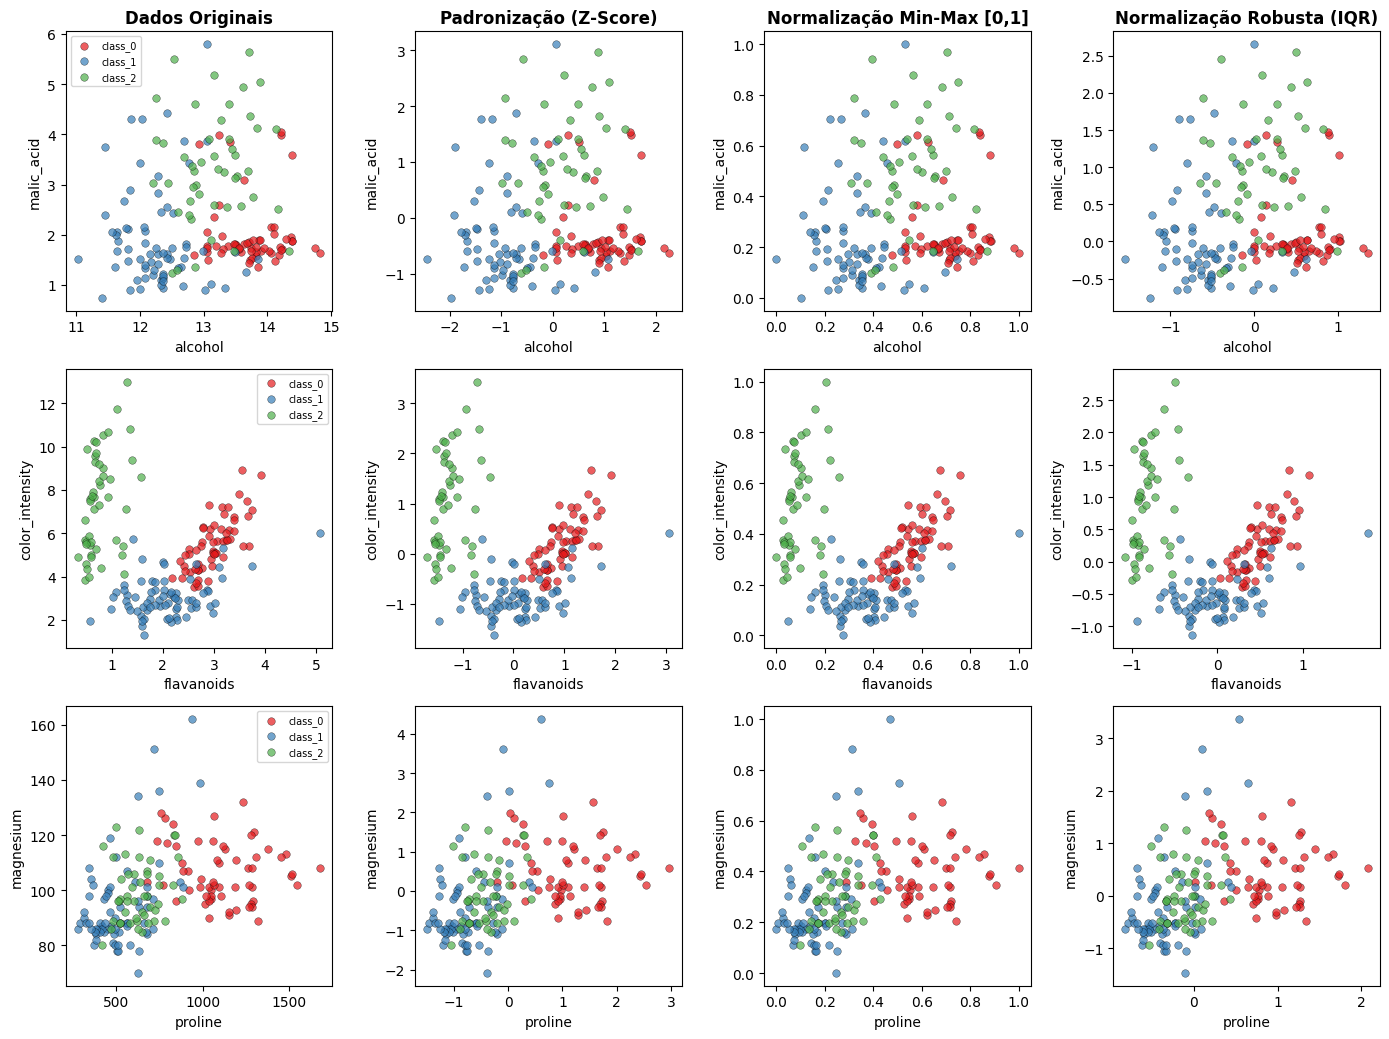

In [8]:
# Pares de atributos interessantes para visualização
pairs = [
    ('alcohol', 'malic_acid'),
    ('flavanoids', 'color_intensity'),
    ('proline', 'magnesium'),
]

fig, axes = plt.subplots(len(pairs), 4, figsize=(14, 3.5 * len(pairs)))

for row, (feat_a, feat_b) in enumerate(pairs):
    ia = feature_names.index(feat_a)
    ib = feature_names.index(feat_b)
    for col, (data, title) in enumerate(datasets):
        ax = axes[row, col]
        for c in range(3):
            mask = y == c
            ax.scatter(data[mask, ia], data[mask, ib],
                       c=colors[c], label=class_names[c],
                       alpha=0.7, edgecolors='k', linewidths=0.3, s=30)
        ax.set_xlabel(feat_a)
        ax.set_ylabel(feat_b)
        if row == 0:
            ax.set_title(title, fontweight='bold')
        if col == 0:
            ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('dispersao_multiplos_pares.png', bbox_inches='tight')
plt.show()

## 6. Estatísticas descritivas antes e depois

In [9]:
def summary_stats(data, name):
    df_tmp = pd.DataFrame(data, columns=feature_names)
    stats = df_tmp.describe().loc[['mean', 'std', 'min', 'max']].round(4)
    print(f"\n{'='*60}")
    print(f" {name}")
    print(f"{'='*60}")
    display(stats)

summary_stats(X, 'Dados Originais')
summary_stats(X_standard, 'Padronização (Z-Score)')
summary_stats(X_minmax, 'Normalização Min-Max')
summary_stats(X_robust, 'Normalização Robusta')


 Dados Originais


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
mean,13.0006,2.3363,2.3665,19.4949,99.7416,2.2951,2.0293,0.3619,1.5909,5.0581,0.9574,2.6117,746.8933
std,0.8118,1.1171,0.2743,3.3396,14.2825,0.6259,0.9989,0.1245,0.5724,2.3183,0.2286,0.7100,314.9075
min,11.0300,0.7400,1.3600,10.6000,70.0000,0.9800,0.3400,0.1300,0.4100,1.2800,0.4800,1.2700,278.0000
max,14.8300,5.8000,3.2300,30.0000,162.0000,3.8800,5.0800,0.6600,3.5800,13.0000,1.7100,4.0000,1680.0000



 Padronização (Z-Score)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
mean,0.0000,0.0000,-0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.0000,0.0000,-0.0000
std,1.0028,1.0028,1.0028,1.0028,1.0028,1.0028,1.0028,1.0028,1.0028,1.0028,1.0028,1.0028,1.0028
min,-2.4342,-1.4330,-3.6792,-2.6710,-2.0883,-2.1072,-1.6960,-1.8682,-2.0690,-1.6343,-2.0947,-1.8951,-1.4932
max,2.2598,3.1092,3.1563,3.1545,4.3714,2.5395,3.0628,2.4024,3.4851,3.4354,3.3017,1.9609,2.9715



 Normalização Min-Max


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
mean,0.5186,0.3155,0.5382,0.4585,0.3233,0.4535,0.3564,0.4375,0.3725,0.3224,0.3882,0.4915,0.3344
std,0.2136,0.2208,0.1467,0.1721,0.1552,0.2158,0.2107,0.2348,0.1806,0.1978,0.1858,0.2601,0.2246
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
max,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000



 Normalização Robusta


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
mean,-0.0376,0.3185,0.0188,-0.0012,0.0917,-0.0566,-0.0633,0.1305,0.0513,0.1235,-0.0224,-0.1366,0.1515
std,0.6174,0.7548,0.7895,0.7766,0.7517,0.5918,0.5981,0.7430,0.8177,0.7779,0.6772,0.5761,0.6500
min,-1.5361,-0.7601,-2.8777,-2.0698,-1.4737,-1.3002,-1.0749,-1.2537,-1.6357,-1.1443,-1.4370,-1.2252,-0.8163
max,1.3536,2.6588,2.5036,2.4419,3.3684,1.4421,1.7635,1.9104,2.8929,2.7886,2.2074,0.9899,2.0774


## 7. Visualização com histogramas: distribuição de um atributo

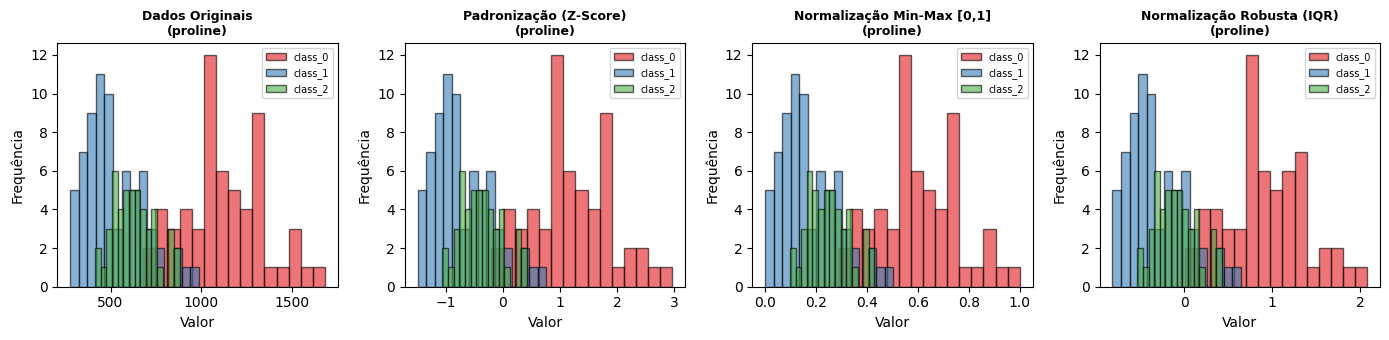

In [10]:
feat_idx = feature_names.index('proline')

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))

for ax, (data, title) in zip(axes, datasets):
    for c in range(3):
        mask = y == c
        ax.hist(data[mask, feat_idx], bins=15, alpha=0.6,
                label=class_names[c], color=colors[c], edgecolor='k')
    ax.set_title(f'{title}\n(proline)', fontweight='bold', fontsize=9)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frequência')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('histogramas_proline.png', bbox_inches='tight')
plt.show()

## 9. Conclusões

1. **A diferença de escala entre atributos distorce a geometria do espaço**, fazendo com que atributos de maior magnitude dominem métricas de distância e algoritmos de otimização.

2. **A padronização (Z-Score)** centraliza os dados e iguala variâncias, sendo ideal para PCA, regressão logística e algoritmos baseados em gradiente.

3. **A normalização Min-Max** mapeia os dados para [0,1], sendo ideal para redes neurais com ativações limitadas e quando não há outliers significativos.

4. **A normalização robusta** é a melhor escolha na presença de outliers, pois usa mediana e IQR em vez de média e desvio padrão.

5. **Nenhuma técnica altera a forma da distribuição** — apenas a escala e posição.